In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
import pandas as pd


features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

10it [00:50,  5.02s/it]


[0.95759076 0.735034   0.6417206  0.5051682  0.45909774 0.4317848
 0.5394771  0.8624701 ]


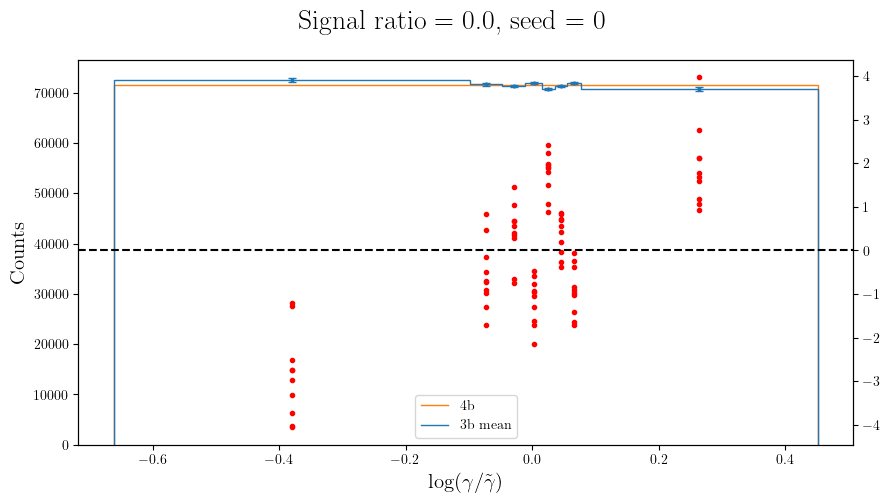

10it [01:00,  6.06s/it]


[1.5949403  0.44173646 0.3778488  0.61221164 0.7485504  0.85594684
 0.85374486 1.5319316 ]


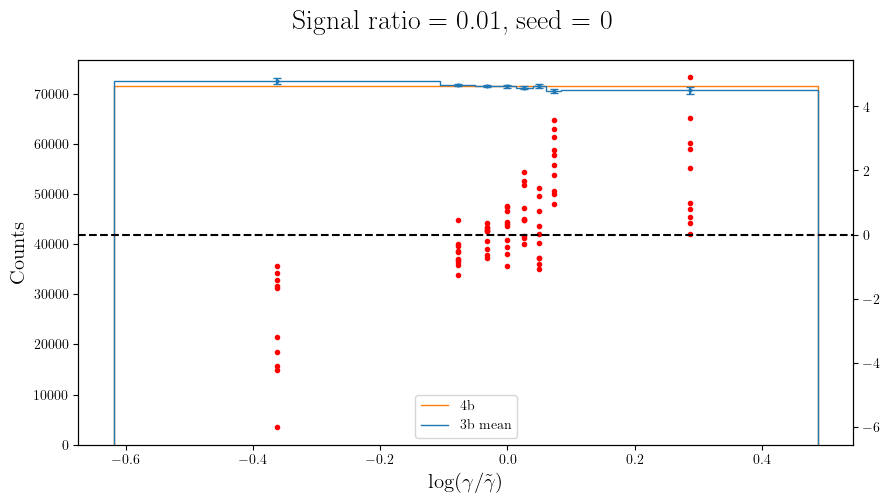

10it [00:59,  5.94s/it]


[1.4537096  0.78289217 0.63024884 0.6355125  0.6582514  0.6079779
 0.5360236  0.4560487 ]


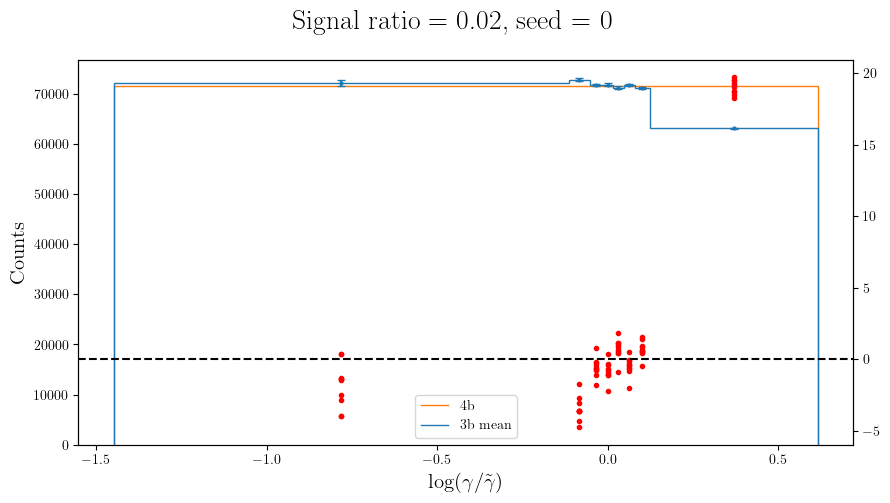

In [6]:
from signal_region import get_SR_CR_cut, get_DRs
from plots import plot_sr_stats
from ancillary_features import get_closest_dijet_masses
from utils import get_quantiles_with_weights

n_3b = 100_0000
ratio_4b = 0.5
signal_filename = "HH4b_picoAOD.h5"
seed = 0
experiment_name = "CR_fvt_training_same_data"

for signal_ratio in [0.0, 0.01, 0.02]:
    hashes = TrainingInfo.find(
            {
                "experiment_name": experiment_name,
                "dataset": lambda x: (
                    x["n_3b"] == n_3b
                    and x["ratio_4b"] == ratio_4b
                    and x["signal_ratio"] == signal_ratio
                    and x["signal_filename"] == signal_filename
                    and x["seed"] == seed
                ),
                "aux_info_step": 3
            }
    )

    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
    smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
    msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
    tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
    events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
    SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]

    np.random.seed(0)
    # random_idx = np.random.choice(len(events_tst), 200_000)
    random_idx = np.arange(len(events_tst))
    events_tst = events_tst[random_idx]
    SR_stats_tst = SR_stats[random_idx]

    fvt_score_list = []
    for ax_cnt, hash in tqdm.tqdm(enumerate(hashes)):
        CR_fvt_tinfo = TrainingInfo.load(hash)
        CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
        CR_fvt_model.eval()
        CR_fvt_model: FvTClassifier
        
        fvt_scores = CR_fvt_model.predict(events_tst.X_torch).cpu().numpy()[:, 1]
        fvt_score_list.append(fvt_scores)
        


    nbins = 8
    reweights_list = [g / (1 - g) for g in fvt_score_list]
    SR_bins = get_quantiles_with_weights(
        SR_stats_tst[events_tst.is_4b],
        events_tst.weights[events_tst.is_4b],
        np.linspace(0, 1, nbins + 1)
    )
    hist_4b = np.histogram(
        SR_stats_tst[events_tst.is_4b],
        bins=SR_bins,
        weights=events_tst.weights[events_tst.is_4b]
    )[0]
    hist_4b_sq = np.histogram(
        SR_stats_tst[events_tst.is_4b],
        bins=SR_bins,
        weights=events_tst.weights[events_tst.is_4b]**2
    )[0]
    hist_3b_rw_list = []
    hist_3b_rw_sq_list = []
    for rw in reweights_list:
        hist_3b_rw = np.histogram(
            SR_stats_tst[events_tst.is_3b],
            bins=SR_bins,
            weights=(rw * events_tst.weights)[events_tst.is_3b]
        )[0]
        hist_3b_rw_list.append(hist_3b_rw)
        hist_3b_rw_sq = np.histogram(
            SR_stats_tst[events_tst.is_3b],
            bins=SR_bins,
            weights=(rw * events_tst.weights)[events_tst.is_3b]**2
        )[0]
        hist_3b_rw_sq_list.append(hist_3b_rw_sq)
        
    T_list = [(hist_4b - hist_3b_rw) / np.sqrt(hist_4b_sq + hist_3b_rw_sq) 
            for hist_3b_rw, hist_3b_rw_sq in zip(hist_3b_rw_list, hist_3b_rw_sq_list)]

    print(np.std(T_list, axis=0))

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(f"Signal ratio = {signal_ratio}, seed = 0")
    ax.set_xlabel("$\log (\gamma / \\tilde{\gamma})$")
    ax.set_ylabel("Counts")
    midpoints = (SR_bins[:-1] + SR_bins[1:]) / 2
    ax.stairs(hist_4b, SR_bins, label="4b", color=plt.get_cmap("tab10").colors[1])
    twinx = ax.twinx()
    hist_3b_mean = np.mean(hist_3b_rw_list, axis=0)
    hist_3b_std = np.std(hist_3b_rw_list, axis=0)
    ax.stairs(hist_3b_mean, SR_bins, label=f"3b mean", color=plt.get_cmap("tab10").colors[0])
    ax.errorbar(midpoints, hist_3b_mean, yerr=hist_3b_std, color=plt.get_cmap("tab10").colors[0]
                , fmt="o", markersize=2, capsize=3)
    for i, (hist_3b, hist_3b_rw_sq) in enumerate(zip(hist_3b_rw_list, hist_3b_rw_sq_list)):
        twinx.plot(midpoints, (hist_4b - hist_3b) / np.sqrt(hist_4b_sq + hist_3b_rw_sq), 
                "o",color="red")
    twinx.axhline(0, color="black", linestyle="--")
    ax.legend()
    plt.show()